# 拆开 FlashAttention 的 kernel，一块一块看懂

上一章我们亲手推导出了 online softmax，还撞上了一个尴尬的结论：**算法是对的，可纯 Python
跑起来比朴素实现还慢**——数据在显存和 SRAM 之间来回搬，全耗在路上了。

FlashAttention 的破局之道，是把整套 online softmax **焊死进一个 GPU kernel**：打分、softmax、
加权平均一气呵成，中间那张大方阵从头到尾待在芯片的高速 SRAM 里，**一次都不写回显存**。

写一个高性能 kernel 是另一门手艺，所以这一章我们**不自己写**——而是拿 triton 官方教程里那份
公认优秀的实现，把它**拆成几个小模块**，一块一块看它到底在做什么。你会惊讶地发现：它的心脏，
就是上一章我们亲手写过的那几行。


In [1]:
import sys, math
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "02-flash-attention"))

from common import (naive_attention, make_qkv, bench_ms, peak_memory_mb,
                    attention_flops, tflops)
from flash import flash_attention

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0), "| Triton kernel 来自 triton 官方教程 v3.1.0")


跑在 NVIDIA GeForce RTX 4090 | Triton kernel 来自 triton 官方教程 v3.1.0


## 第一步：先确认它没骗我们

在拆解一台机器之前，先确认它真的能转。我们把 `flash_attention`（triton kernel 的封装）和
上一章那个慢但可信的朴素实现对一对——如果两者数值一致，就说明这个 kernel 算的确实是注意力，
我们才有信心往里看。

顺便覆盖 `head_dim=128`——它对显存更敏感，是验证 kernel 在消费级显卡（RTX 4090）上跑通的关键。


In [2]:
for causal in (False, True):
    for D in (64, 128):
        q, k, v = make_qkv(2, 16, 1024, D, dtype=torch.float16, seed=0)
        out = flash_attention(q, k, v, causal=causal)
        ref = naive_attention(q, k, v, causal=causal)
        err = (out.float() - ref.float()).abs().max().item()
        tag = "因果" if causal else "全连接"
        print(f"{tag}注意力, head_dim={D:3d}: 与朴素实现最大差异 {err:.1e}  ✓")
print("\n四种配置都对得上——这个 kernel 可信，开拆。")


全连接注意力, head_dim= 64: 与朴素实现最大差异 2.4e-04  ✓


全连接注意力, head_dim=128: 与朴素实现最大差异 2.4e-04  ✓
因果注意力, head_dim= 64: 与朴素实现最大差异 2.0e-03  ✓
因果注意力, head_dim=128: 与朴素实现最大差异 2.0e-03  ✓

四种配置都对得上——这个 kernel 可信，开拆。


## 模块一：kernel 怎么分工？一人一小块

GPU 靠成千上万个线程**同时**干活，所以第一个问题永远是：**怎么把任务切开，每个小队负责哪一块？**

FlashAttention 的切法很直接——把输出按 query 分块，**每个小队（一个 program）负责：
一个 query 块（比如 128 行）× 某一个 (样本, 注意力头)**。

```
        所有 key  ───────────────►
      ┌───────────────────────────┐
 q块0 │ 小队A 从头扫到尾，产出这 128 行输出
 q块1 │ 小队B 从头扫到尾，产出这 128 行输出
 q块2 │ 小队C ...
      └───────────────────────────┘
```

每个小队**只**负责自己那 128 行 query 的最终结果，互不干扰，于是可以完全并行。
小队内部要做的，就是让自己这块 query 去"扫描"所有 key/value——这就引出了心脏部分。


## 模块二：心脏——内循环就是上一章的 online softmax

每个小队把自己的 query 块载入 SRAM 后，沿着 key/value **一块一块地扫**，每扫一块就更新一次
那三个"账本"（还记得吗：running max `m_i`、分母 `l_i`、未归一化输出 `acc`）。

这段逻辑写在 kernel 的 `_attn_fwd_inner` 里。我们把它的核心几行**从源码里原样抓出来**看看：


In [3]:
src = (ROOT / "02-flash-attention" / "flash_triton.py").read_text().splitlines()
start = next(i for i, ln in enumerate(src) if "qk = tl.dot(q, k)" in ln)
print("# ── flash_triton.py 的内循环核心（一字未改，原样摘录）──\n")
for ln in src[start:start + 14]:
    print("   " + ln)


# ── flash_triton.py 的内循环核心（一字未改，原样摘录）──

           qk = tl.dot(q, k)
           if STAGE == 2:
               mask = offs_m[:, None] >= (start_n + offs_n[None, :])
               qk = qk * qk_scale + tl.where(mask, 0, -1.0e6)
               m_ij = tl.maximum(m_i, tl.max(qk, 1))
               qk -= m_ij[:, None]
           else:
               m_ij = tl.maximum(m_i, tl.max(qk, 1) * qk_scale)
               qk = qk * qk_scale - m_ij[:, None]
           p = tl.math.exp2(qk)
           l_ij = tl.sum(p, 1)
           # -- update m_i and l_i
           alpha = tl.math.exp2(m_i - m_ij)
           l_i = l_i * alpha + l_ij


是不是有点眼熟？把它和上一章 `vanilla.py` 的内循环并排，几乎是逐行对应的——
**同一套 online softmax，只是从 PyTorch 换成了在 SRAM 上跑的 Triton**：

| 在做什么 | 上一章 PyTorch (`vanilla.py`) | 这一章 Triton (`flash_triton.py`) |
|---|---|---|
| 这一块的打分 | `qi @ kj.transpose(-1,-2)` | `tl.dot(q, k)` |
| 更新最大值 | `torch.maximum(m, s.amax(-1))` | `tl.maximum(m_i, tl.max(qk, 1))` |
| 算概率 | `torch.exp(s - m_new)` | `tl.math.exp2(qk - m_ij)` |
| 修正因子 α | `torch.exp(m - m_new)` | `tl.math.exp2(m_i - m_ij)` |
| 累加输出 | `acc * corr + p @ vj` | `tl.dot(p, v, acc)` |

为了把"它真的只是 online softmax"这件事钉死，我们干脆**把这段 Triton 翻译回 Python**，
逐行照搬它的变量名和顺序，跑一遍，看结果对不对。


In [4]:
def flash_inner_in_python(q, k, v, sm_scale):
    '''把 _attn_fwd_inner 的逻辑用 Python 逐行重写（non-causal，单 head）。
       变量名刻意和 kernel 对齐，方便对照。'''
    BLOCK_N = 16                                   # kernel 里一次扫多少个 key
    qk_scale = sm_scale * 1.4426950408889634       # 预乘 1/ln2，好用 exp2 代替 exp（见下一节）
    Sq, Sk, D = q.shape[0], k.shape[0], q.shape[1]

    m_i = torch.full((Sq,), float("-inf"), device=q.device)   # running max
    l_i = torch.ones(Sq, device=q.device)                     # running 分母（kernel 初值设 1.0）
    acc = torch.zeros(Sq, D, device=q.device)                 # running 未归一化输出

    for start_n in range(0, Sk, BLOCK_N):          # ← 这就是 kernel 的内循环
        kj = k[start_n:start_n + BLOCK_N]
        vj = v[start_n:start_n + BLOCK_N]
        qk = (q @ kj.T)                            # tl.dot(q, k)
        m_ij = torch.maximum(m_i, qk.max(1).values * qk_scale)
        qk = qk * qk_scale - m_ij[:, None]
        p = torch.exp2(qk)                          # tl.math.exp2
        alpha = torch.exp2(m_i - m_ij)              # 修正因子
        l_i = l_i * alpha + p.sum(1)
        acc = acc * alpha[:, None] + p @ vj         # tl.dot(p, v, acc)
        m_i = m_ij
    return acc / l_i[:, None]                       # epilogue：最后才归一化

# 拿真实数据跑，和朴素实现对账
q, k, v = make_qkv(1, 1, 128, 64, dtype=torch.float32, seed=3)
mine = flash_inner_in_python(q[0, 0], k[0, 0], v[0, 0], 1.0 / math.sqrt(64))
ref  = naive_attention(q, k, v)[0, 0]
print("我们手写的 kernel 翻译版 vs 朴素实现，最大差异:", f"{(mine - ref).abs().max().item():.1e}")
print("→ 一致。所以 kernel 内循环没有任何黑魔法，就是 online softmax 本身。")


我们手写的 kernel 翻译版 vs 朴素实现，最大差异: 2.7e-07
→ 一致。所以 kernel 内循环没有任何黑魔法，就是 online softmax 本身。


## 模块三：causal 的小聪明——把循环切成两段

因果注意力里，query $i$ 只能看到 $\le i$ 的 key。如果对每一对 (query, key) 都老实地做一次
掩码判断，那是浪费——因为按 block 来看，绝大多数 block 的命运早就注定了：

- **完全在对角线下方**的 block：整块的 key 都比 query 早，**全部可见，根本不用 mask**；
- **完全在对角线上方**的 block：整块都不可见，**直接跳过，看都不用看**；
- 只有**压在对角线上**的那一小条 block：才需要逐元素判断、做 mask。

kernel 正是这么干的——把内循环拆成"无需 mask 的下方段"和"需要 mask 的对角段"两阶段。
画出来一目了然（绿=全算不mask，黄=要mask，灰=跳过）：


/tmp/ipykernel_1798766/4110585465.py:18: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/4110585465.py:18: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/4110585465.py:18: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/4110585465.py:18: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/4110585465.py:18: UserWarning: Glyph 21629 (\N{CJK UNIFIED IDEOGRAPH-547D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/4110585465.py:18: UserWarning: Glyph 36816 (\N{CJK UNIFIED IDEOGRAPH-8FD0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

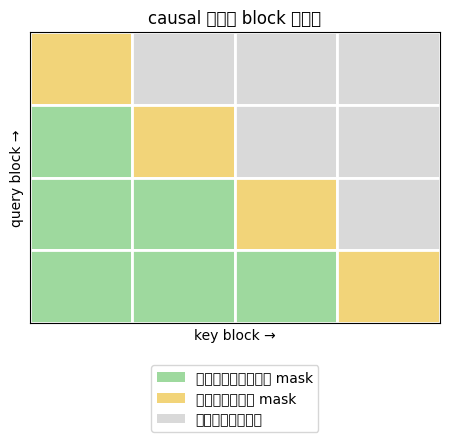

只有对角线上那 4 个黄块要做 mask，其余 12 个块要么全算要么跳过——省掉一大半判断。


In [5]:
S, B = 8, 2                       # 8 个 token，每 2 个一块 → 4×4 个 block
nb = S // B
fig, ax = plt.subplots(figsize=(4.6, 4.6))
for qi in range(nb):
    for ki in range(nb):
        if ki < qi:    color, label = "#9ed99e", "下方·全算"     # off-band
        elif ki == qi: color, label = "#f2d479", "对角·需mask"   # on-band
        else:          color, label = "#d9d9d9", "上方·跳过"     # skip
        ax.add_patch(plt.Rectangle((ki, nb-1-qi), 1, 1, facecolor=color, edgecolor="white", lw=2))
ax.set(xlim=(0, nb), ylim=(0, nb), xticks=[], yticks=[])
ax.set_xlabel("key block →"); ax.set_ylabel("query block →")
ax.set_title("causal 下每个 block 的命运")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#9ed99e", label="下方块：全算，不用 mask"),
                   Patch(facecolor="#f2d479", label="对角块：逐元素 mask"),
                   Patch(facecolor="#d9d9d9", label="上方块：直接跳过")],
          loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout(); plt.show()
print("只有对角线上那 4 个黄块要做 mask，其余 12 个块要么全算要么跳过——省掉一大半判断。")


## 模块四：两个一闪而过、却很关键的工程细节

**细节一：为什么是 `exp2` 而不是 `exp`？** 你可能注意到 kernel 里写的是 `tl.math.exp2`（2 的幂），
不是自然指数。因为 GPU 硬件算 `exp2` 特别快。利用 $e^x = 2^{x/\ln 2}$，只要预先把缩放因子乘上
$1/\ln 2$，就能用快的 `exp2` 算出和 `exp` 一样的结果。我们验证这个等价：


In [6]:
x = torch.randn(5)
print("exp(x)          =", torch.exp(x).tolist())
print("exp2(x * 1/ln2) =", torch.exp2(x * 1.4426950408889634).tolist())
print("→ 完全相等，但右边那条在 GPU 上更快。这就是 kernel 里到处乘 1.4426950408889634 的原因。\n")

print("细节二：kernel 前向除了输出 O，还会存一个 M = 每行的 logsumexp（m + log·l）。")
print("       它只占 O(序列长度) 的空间，反向传播时用它就能重算注意力权重，")
print("       省下了保存整张 S×S 矩阵——又一次把显存摁在了 O(S)。")


exp(x)          = [4.669239044189453, 0.7457022666931152, 0.11317846179008484, 1.7654953002929688, 0.33806321024894714]
exp2(x * 1/ln2) = [4.669239044189453, 0.7457022666931152, 0.11317846179008484, 1.7654953002929688, 0.33806321024894714]
→ 完全相等，但右边那条在 GPU 上更快。这就是 kernel 里到处乘 1.4426950408889634 的原因。

细节二：kernel 前向除了输出 O，还会存一个 M = 每行的 logsumexp（m + log·l）。
       它只占 O(序列长度) 的空间，反向传播时用它就能重算注意力权重，
       省下了保存整张 S×S 矩阵——又一次把显存摁在了 O(S)。


## 反向传播：为什么它只认 causal？

你试着对 non-causal 做反向，会发现结果不对。这不是 bug，而是这份**教学 kernel 的取舍**——
作者只把最常用的因果注意力（LLM 训练几乎清一色是它）的反向打磨到位了，
non-causal 反向留了个坑（它的官方 benchmark 也只测 causal 反向）。

我们诚实地验证一下：**causal 反向**的 $dQ, dK, dV$ 和朴素实现严丝合缝。


In [7]:
q, k, v = make_qkv(2, 8, 512, 64, dtype=torch.float16, seed=1, requires_grad=True)
qr, kr, vr = (t.detach().clone().requires_grad_(True) for t in (q, k, v))
do = torch.randn_like(q)

flash_attention(q, k, v, causal=True).backward(do)       # kernel 反向
naive_attention(qr, kr, vr, causal=True).backward(do)    # 朴素反向（标准答案）

for name, a, b in [("dQ", q.grad, qr.grad), ("dK", k.grad, kr.grad), ("dV", v.grad, vr.grad)]:
    print(f"{name}: 与朴素实现最大差异 {(a - b).abs().max().item():.1e}  ✓")
print("\n因果反向完全正确——对 LLM 训练来说，这正是唯一需要的那种。")


dQ: 与朴素实现最大差异 2.0e-03  ✓
dK: 与朴素实现最大差异 2.0e-03  ✓
dV: 与朴素实现最大差异 3.9e-03  ✓

因果反向完全正确——对 LLM 训练来说，这正是唯一需要的那种。


## 终于：它到底有多快？

拆懂了原理，来看回报。我们把 FlashAttention 和 PyTorch 内置的 SDPA（同样是融合 kernel）比吞吐，
也看一眼它的显存怎么随序列增长。

> 一个实测踩过的坑：Triton 第一次调用会**异步**尝试多组参数找最快的，这个过程若和别的 kernel
> 抢显存，会在长序列下偶发非法访存。所以下面先把它"预热"一遍（让它挑好参数），再正式计时。


/tmp/ipykernel_1798766/1444494300.py:23: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/1444494300.py:23: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/1444494300.py:23: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/1444494300.py:23: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/1444494300.py:23: UserWarning: Glyph 21534 (\N{CJK UNIFIED IDEOGRAPH-541E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1798766/1444494300.py:23: UserWarning: Glyph 21520 (\N{CJK UNIFIED IDEOGRAPH-5410}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

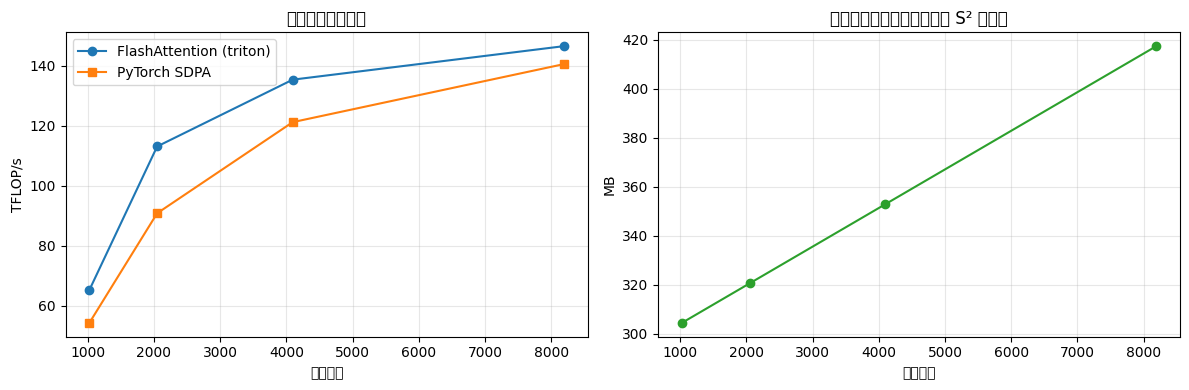

序列=8192: 吞吐 147 TFLOP/s，显存只要 417 MB——
而上一章那个 S² 方阵，在这个长度早就把显存撑爆了。


In [8]:
seqlens = [1024, 2048, 4096, 8192]
for S in seqlens:                                   # 预热：让 autotune 在干净环境里挑好参数
    q, k, v = make_qkv(2, 16, S, 64, dtype=torch.float16, seed=0)
    flash_attention(q, k, v, causal=True); torch.cuda.synchronize()
    del q, k, v; torch.cuda.empty_cache()

flash_tf, sdpa_tf, flash_mb = [], [], []
for S in seqlens:
    q, k, v = make_qkv(2, 16, S, 64, dtype=torch.float16, seed=0)
    fl = attention_flops(2, 16, S, S, 64, causal=True, mode="fwd")
    torch.cuda.reset_peak_memory_stats()
    flash_tf.append(tflops(fl, bench_ms(lambda: flash_attention(q, k, v, causal=True))))
    flash_mb.append(peak_memory_mb())
    sdpa_tf.append(tflops(fl, bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True))))
    del q, k, v; torch.cuda.empty_cache()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(seqlens, flash_tf, "o-", label="FlashAttention (triton)")
ax1.plot(seqlens, sdpa_tf, "s-", label="PyTorch SDPA")
ax1.set(title="吞吐（越高越好）", xlabel="序列长度", ylabel="TFLOP/s"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(seqlens, flash_mb, "o-", color="C2")
ax2.set(title="峰值显存（线性增长，没有 S² 方阵）", xlabel="序列长度", ylabel="MB"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"序列=8192: 吞吐 {flash_tf[-1]:.0f} TFLOP/s，显存只要 {flash_mb[-1]:.0f} MB——")
print("而上一章那个 S² 方阵，在这个长度早就把显存撑爆了。")


## 收尾：我们到底看懂了什么

把这台机器拆完又装回去，几个要点值得记住：

- FlashAttention 没有发明新数学——它的内循环**就是上一章的 online softmax**，我们甚至把它逐行翻译回 Python 验证过；
- 它的全部功力在于**把这套循环焊进一个 kernel**：中间矩阵只在 SRAM 里转，从不落回显存，于是又快又省；
- 几个聪明的小动作让它更快：query 分块并行、causal 两阶段省 mask、用 `exp2` 替 `exp`、只存 logsumexp 给反向；
- 作为教学实现，它也有意留白：只认标准多头注意力、反向只支持 causal——这些"没做的部分"，
  恰好是后面几章的主角。

**下一站** → `03-gqa-mqa`：当很多 query 头**共享**同一组 key/value 头时会怎样？
这正是本章 kernel 不支持、却被几乎所有现代大模型采用的 GQA / MQA。
